In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38
0,ACSM1,10.914760,11.135962,8.891566,8.074361,9.557551,10.132283,10.019072,8.925043,11.817970,...,7.659350,6.397556,6.226404,5.630004,7.850567,6.779979,5.882256,10.540738,7.262209,7.532407
1,ADORA2B,5.110096,5.805840,4.750283,5.620902,5.434974,5.514895,4.450006,6.229374,4.439311,...,6.540154,5.116456,5.080135,7.398721,6.450155,3.579958,5.938070,6.692122,6.385460,5.950856
2,AGPAT1,3.896571,5.078981,4.389263,5.705530,5.356997,5.326282,5.437688,4.551041,2.857657,...,5.213546,5.277771,6.954467,7.280251,6.796259,8.176044,6.867025,6.206010,7.782533,6.400674
3,BTBD16,6.838794,6.487988,6.991046,5.690952,6.632153,6.535228,6.927929,4.979223,7.734810,...,4.949167,4.854093,2.889749,5.578432,5.914876,6.037106,4.780228,3.544489,3.142159,4.833111
4,CCDC178,6.137514,6.115845,5.544265,6.502288,8.371001,6.477630,8.866079,5.789687,5.656918,...,4.466889,4.313042,3.611286,4.570975,5.151161,3.790559,4.200692,4.406053,4.664216,4.987756


In [ ]:
data = data.T

In [ ]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)
X


,ACSM1,ADORA2B,AGPAT1,BTBD16,CCDC178,CD207,CLRN1,CMA1,CSMD1,DDT,...,SFRP4,SIK1,SLC2A14,SORCS3,STC1,TBC1D3L,TNFRSF17,TYR,USP17L2,WDR46
1,10.914760,5.110096,3.896571,6.838794,6.137514,6.335811,6.009826,4.404689,8.698855,3.646425,...,12.193521,5.697186,2.974660,5.043856,6.742106,4.391362,5.723762,7.119836,8.620417,4.919325
2,11.135962,5.805840,5.078981,6.487988,6.115845,4.977656,5.474359,5.221860,7.239703,3.538015,...,10.480460,5.022233,4.247290,4.857951,4.822149,4.373500,6.082677,6.200747,8.470901,4.877400
3,8.891566,4.750283,4.389263,6.991046,5.544265,5.854893,6.827014,5.897843,10.042353,4.492789,...,11.926017,4.880500,3.793164,3.881190,7.631016,4.571990,5.470134,5.550446,8.192874,3.748831
4,8.074361,5.620902,5.705530,5.690952,6.502288,5.733583,4.652300,5.626731,8.580342,3.771152,...,13.494115,6.238118,2.781264,5.574711,8.175455,4.230194,6.473276,5.648787,7.811523,3.628753
5,9.557551,5.434974,5.356997,6.632153,8.371001,6.031605,5.919477,4.324369,7.790120,3.969257,...,11.788102,6.211392,3.135282,3.558551,6.543452,4.989646,6.105548,6.003599,7.399032,4.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6.779979,3.579958,8.176044,6.037106,3.790559,5.955599,8.112708,3.799325,6.478235,3.457107,...,10.890283,6.371103,5.944549,7.714985,9.056544,2.989828,5.051926,4.590912,7.227312,7.534752
68,5.882256,5.938070,6.867025,4.780228,4.200692,7.120193,7.008641,5.275480,6.822246,3.674302,...,11.551356,4.638456,5.725493,7.030303,9.135109,4.425790,4.721240,4.575075,6.103253,6.043637
69,10.540738,6.692122,6.206010,3.544489,4.406053,8.428116,6.119198,3.879046,8.752773,3.514716,...,9.344778,6.806512,4.146754,4.050462,10.532865,5.542763,4.414228,4.553074,5.016077,5.212523
70,7.262209,6.385460,7.782533,3.142159,4.664216,6.850532,4.242906,4.150065,6.151992,5.022798,...,10.195798,9.094513,3.853907,4.198532,11.917931,5.721694,5.591699,2.992995,2.595225,4.808556


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import json
import numpy as np
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/ADA/10_10"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
    algorithm='SAMME'
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'estimator__max_depth': [1, 2, 3],
    'n_estimators':         [100, 200, 300],
    'learning_rate':        [0.01, 0.1, 0.5, 1.0]
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index   = grid_search.best_index_
cv_results   = grid_search.cv_results_
train_score  = cv_results['mean_train_score'][best_index]
test_score   = cv_results['mean_test_score'][best_index]
std_score    = cv_results['std_test_score'][best_index]
best_model   = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions on full data (or swap X with X_test if you have a holdout set) ──
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "adaboost_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model         → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":        grid_search.best_params_,
    "best_cv_accuracy":   round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy":   round(test_score * 100, 4),
    "std_deviation":      round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid       → {cv_json_path}")

# ── 4. Save confusion matrix (.txt) ──────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")
with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))
print(f"[Saved] Confusion Mat → {cm_path}")

# ── 5. Save classification report (.txt) ─────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))
print(f"[Saved] Class Report  → {report_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 100 folds for each of 36 candidates, totalling 3600 fits


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best Parameters     : {'estimator__max_depth': 1, 'learning_rate': 0.5, 'n_estimators': 200}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model         → /content/drive/MyDrive/ADA/10_10/adaboost_best_model.pkl
[Saved] Params+Scores → /content/drive/MyDrive/ADA/10_10/best_params_scores.json
[Saved] CV Grid       → /content/drive/MyDrive/ADA/10_10/cv_results_grid.json
[Saved] Confusion Mat → /content/drive/MyDrive/ADA/10_10/confusion_matrix.txt
[Saved] Class Report  → /content/drive/MyDrive/ADA/10_10/classification_report.txt

✅ All files saved to: /content/driv

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import json
import numpy as np
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/ADA/10_5"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
    algorithm='SAMME'
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'estimator__max_depth': [1, 2, 3],
    'n_estimators':         [100, 200, 300],
    'learning_rate':        [0.01, 0.1, 0.5, 1.0]
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index   = grid_search.best_index_
cv_results   = grid_search.cv_results_
train_score  = cv_results['mean_train_score'][best_index]
test_score   = cv_results['mean_test_score'][best_index]
std_score    = cv_results['std_test_score'][best_index]
best_model   = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions on full data (or swap X with X_test if you have a holdout set) ──
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "adaboost_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model         → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":        grid_search.best_params_,
    "best_cv_accuracy":   round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy":   round(test_score * 100, 4),
    "std_deviation":      round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid       → {cv_json_path}")

# ── 4. Save confusion matrix (.txt) ──────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")
with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))
print(f"[Saved] Confusion Mat → {cm_path}")

# ── 5. Save classification report (.txt) ─────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))
print(f"[Saved] Class Report  → {report_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 50 folds for each of 36 candidates, totalling 1800 fits


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best Parameters     : {'estimator__max_depth': 1, 'learning_rate': 0.5, 'n_estimators': 200}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model         → /content/drive/MyDrive/ADA/10_5/adaboost_best_model.pkl
[Saved] Params+Scores → /content/drive/MyDrive/ADA/10_5/best_params_scores.json
[Saved] CV Grid       → /content/drive/MyDrive/ADA/10_5/cv_results_grid.json
[Saved] Confusion Mat → /content/drive/MyDrive/ADA/10_5/confusion_matrix.txt
[Saved] Class Report  → /content/drive/MyDrive/ADA/10_5/classification_report.txt

✅ All files saved to: /content/drive/MyD

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import json
import numpy as np
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/ADA/10_2"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
    algorithm='SAMME'
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'estimator__max_depth': [1, 2, 3],
    'n_estimators':         [100, 200, 300],
    'learning_rate':        [0.01, 0.1, 0.5, 1.0]
}

# ── Repeated Stratified K-Fold ────────────────────────────────────
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=rskf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index   = grid_search.best_index_
cv_results   = grid_search.cv_results_
train_score  = cv_results['mean_train_score'][best_index]
test_score   = cv_results['mean_test_score'][best_index]
std_score    = cv_results['std_test_score'][best_index]
best_model   = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Predictions on full data (or swap X with X_test if you have a holdout set) ──
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "adaboost_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model         → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":        grid_search.best_params_,
    "best_cv_accuracy":   round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy": round(train_score * 100, 4),
    "mean_cv_accuracy":   round(test_score * 100, 4),
    "std_deviation":      round(std_score * 100, 4)
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid       → {cv_json_path}")

# ── 4. Save confusion matrix (.txt) ──────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")
with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))
print(f"[Saved] Confusion Mat → {cm_path}")

# ── 5. Save classification report (.txt) ─────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))
print(f"[Saved] Class Report  → {report_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 20 folds for each of 36 candidates, totalling 720 fits


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best Parameters     : {'estimator__max_depth': 1, 'learning_rate': 0.5, 'n_estimators': 200}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model         → /content/drive/MyDrive/ADA/10_2/adaboost_best_model.pkl
[Saved] Params+Scores → /content/drive/MyDrive/ADA/10_2/best_params_scores.json
[Saved] CV Grid       → /content/drive/MyDrive/ADA/10_2/cv_results_grid.json
[Saved] Confusion Mat → /content/drive/MyDrive/ADA/10_2/confusion_matrix.txt
[Saved] Class Report  → /content/drive/MyDrive/ADA/10_2/classification_report.txt

✅ All files saved to: /content/drive/MyD

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import json
import numpy as np
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/ADA/only5"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
    algorithm='SAMME'
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'estimator__max_depth': [1, 2, 3],
    'n_estimators':         [100, 200, 300],
    'learning_rate':        [0.01, 0.1, 0.5, 1.0]
}

# ── Stratified K-Fold (no repeats) ────────────────────────────────
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Per-fold scores of best estimator ────────────────────────────
fold_scores = [cv_results[f'split{i}_test_score'][best_index] for i in range(5)]
print("\nPer-Fold Accuracies :")
for i, s in enumerate(fold_scores, 1):
    print(f"  Fold {i} : {s*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "adaboost_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model         → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":          grid_search.best_params_,
    "best_cv_accuracy":     round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy":  round(train_score * 100, 4),
    "mean_cv_accuracy":     round(test_score * 100, 4),
    "std_deviation":        round(std_score * 100, 4),
    "per_fold_accuracies":  [round(s * 100, 4) for s in fold_scores]
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid       → {cv_json_path}")

# ── 4. Save confusion matrix (.txt) ──────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")
with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))
print(f"[Saved] Confusion Mat → {cm_path}")

# ── 5. Save classification report (.txt) ─────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))
print(f"[Saved] Class Report  → {report_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 5 folds for each of 36 candidates, totalling 180 fits


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best Parameters     : {'estimator__max_depth': 1, 'learning_rate': 0.1, 'n_estimators': 100}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Per-Fold Accuracies :
  Fold 1 : 100.00%
  Fold 2 : 100.00%
  Fold 3 : 100.00%
  Fold 4 : 100.00%
  Fold 5 : 100.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model         → /content/drive/MyDrive/ADA/only5/adaboost_best_model.pkl
[Saved] Params+Scores → /content/drive/MyDrive/ADA/only5/best_params_scores.json
[Saved] CV Grid       → /content/drive/MyDrive/ADA/only5/cv_results_grid.json
[Saved] Confusion Mat → /content/drive/MyDrive/ADA/only5/confusion_matrix.txt
[

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib
import json
import numpy as np
import os

# ── Output directory ──────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/ADA/only10"
os.makedirs(save_dir, exist_ok=True)

# ── Define base model ─────────────────────────────────────────────
model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),
    random_state=42,
    algorithm='SAMME'
)

# ── Hyperparameter grid ───────────────────────────────────────────
param_grid = {
    'estimator__max_depth': [1, 2, 3],
    'n_estimators':         [100, 200, 300],
    'learning_rate':        [0.01, 0.1, 0.5, 1.0]
}

# ── Stratified K-Fold (no repeats) ────────────────────────────────
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# ── Grid Search ───────────────────────────────────────────────────
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=skf,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

grid_search.fit(X, y)

# ── Extract results ───────────────────────────────────────────────
best_index  = grid_search.best_index_
cv_results  = grid_search.cv_results_
train_score = cv_results['mean_train_score'][best_index]
test_score  = cv_results['mean_test_score'][best_index]
std_score   = cv_results['std_test_score'][best_index]
best_model  = grid_search.best_estimator_

# ── Console output ────────────────────────────────────────────────
print("=" * 50)
print(f"Best Parameters     : {grid_search.best_params_}")
print(f"Best CV Accuracy    : {grid_search.best_score_*100:.2f}%")
print("=" * 50)
print(f"Mean Train Accuracy : {train_score*100:.2f}%")
print(f"Mean CV Accuracy    : {test_score*100:.2f}%")
print(f"Std Deviation       : {std_score*100:.2f}%")

# ── Per-fold scores of best estimator ────────────────────────────
fold_scores = [cv_results[f'split{i}_test_score'][best_index] for i in range(5)]
print("\nPer-Fold Accuracies :")
for i, s in enumerate(fold_scores, 1):
    print(f"  Fold {i} : {s*100:.2f}%")

# ── Predictions ───────────────────────────────────────────────────
y_pred = best_model.predict(X)

print("\nClassification Report:")
print(classification_report(y, y_pred))

# ── 1. Save best model (.pkl) ─────────────────────────────────────
model_path = os.path.join(save_dir, "adaboost_best_model.pkl")
joblib.dump(best_model, model_path)
print(f"\n[Saved] Model         → {model_path}")

# ── 2. Save best params + scores (.json) ─────────────────────────
results_dict = {
    "best_params":          grid_search.best_params_,
    "best_cv_accuracy":     round(grid_search.best_score_ * 100, 4),
    "mean_train_accuracy":  round(train_score * 100, 4),
    "mean_cv_accuracy":     round(test_score * 100, 4),
    "std_deviation":        round(std_score * 100, 4),
    "per_fold_accuracies":  [round(s * 100, 4) for s in fold_scores]
}
json_path = os.path.join(save_dir, "best_params_scores.json")
with open(json_path, "w") as f:
    json.dump(results_dict, f, indent=4)
print(f"[Saved] Params+Scores → {json_path}")

# ── 3. Save full cv_results grid (.json) ──────────────────────────
cv_results_serializable = {
    k: v.tolist() if isinstance(v, np.ndarray) else list(v)
    for k, v in cv_results.items()
}
cv_json_path = os.path.join(save_dir, "cv_results_grid.json")
with open(cv_json_path, "w") as f:
    json.dump(cv_results_serializable, f, indent=4)
print(f"[Saved] CV Grid       → {cv_json_path}")

# ── 4. Save confusion matrix (.txt) ──────────────────────────────
cm_path = os.path.join(save_dir, "confusion_matrix.txt")
with open(cm_path, "w") as f:
    f.write("Confusion Matrix\n")
    f.write("=" * 30 + "\n")
    f.write(np.array2string(confusion_matrix(y, y_pred)))
print(f"[Saved] Confusion Mat → {cm_path}")

# ── 5. Save classification report (.txt) ─────────────────────────
report_path = os.path.join(save_dir, "classification_report.txt")
with open(report_path, "w") as f:
    f.write("Classification Report\n")
    f.write("=" * 30 + "\n")
    f.write(classification_report(y, y_pred))
print(f"[Saved] Class Report  → {report_path}")

print("\n✅ All files saved to:", os.path.abspath(save_dir))

Fitting 10 folds for each of 36 candidates, totalling 360 fits


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


Best Parameters     : {'estimator__max_depth': 1, 'learning_rate': 0.5, 'n_estimators': 200}
Best CV Accuracy    : 100.00%
Mean Train Accuracy : 100.00%
Mean CV Accuracy    : 100.00%
Std Deviation       : 0.00%

Per-Fold Accuracies :
  Fold 1 : 100.00%
  Fold 2 : 100.00%
  Fold 3 : 100.00%
  Fold 4 : 100.00%
  Fold 5 : 100.00%

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        33
         1.0       1.00      1.00      1.00        38

    accuracy                           1.00        71
   macro avg       1.00      1.00      1.00        71
weighted avg       1.00      1.00      1.00        71


[Saved] Model         → /content/drive/MyDrive/ADA/only10/adaboost_best_model.pkl
[Saved] Params+Scores → /content/drive/MyDrive/ADA/only10/best_params_scores.json
[Saved] CV Grid       → /content/drive/MyDrive/ADA/only10/cv_results_grid.json
[Saved] Confusion Mat → /content/drive/MyDrive/ADA/only10/confusion_matrix.t

In [ ]:
import pickle
best_model = joblib.load('/content/drive/MyDrive/ADA/10_2/adaboost_best_model.pkl')

# Open the file in read-binary mode



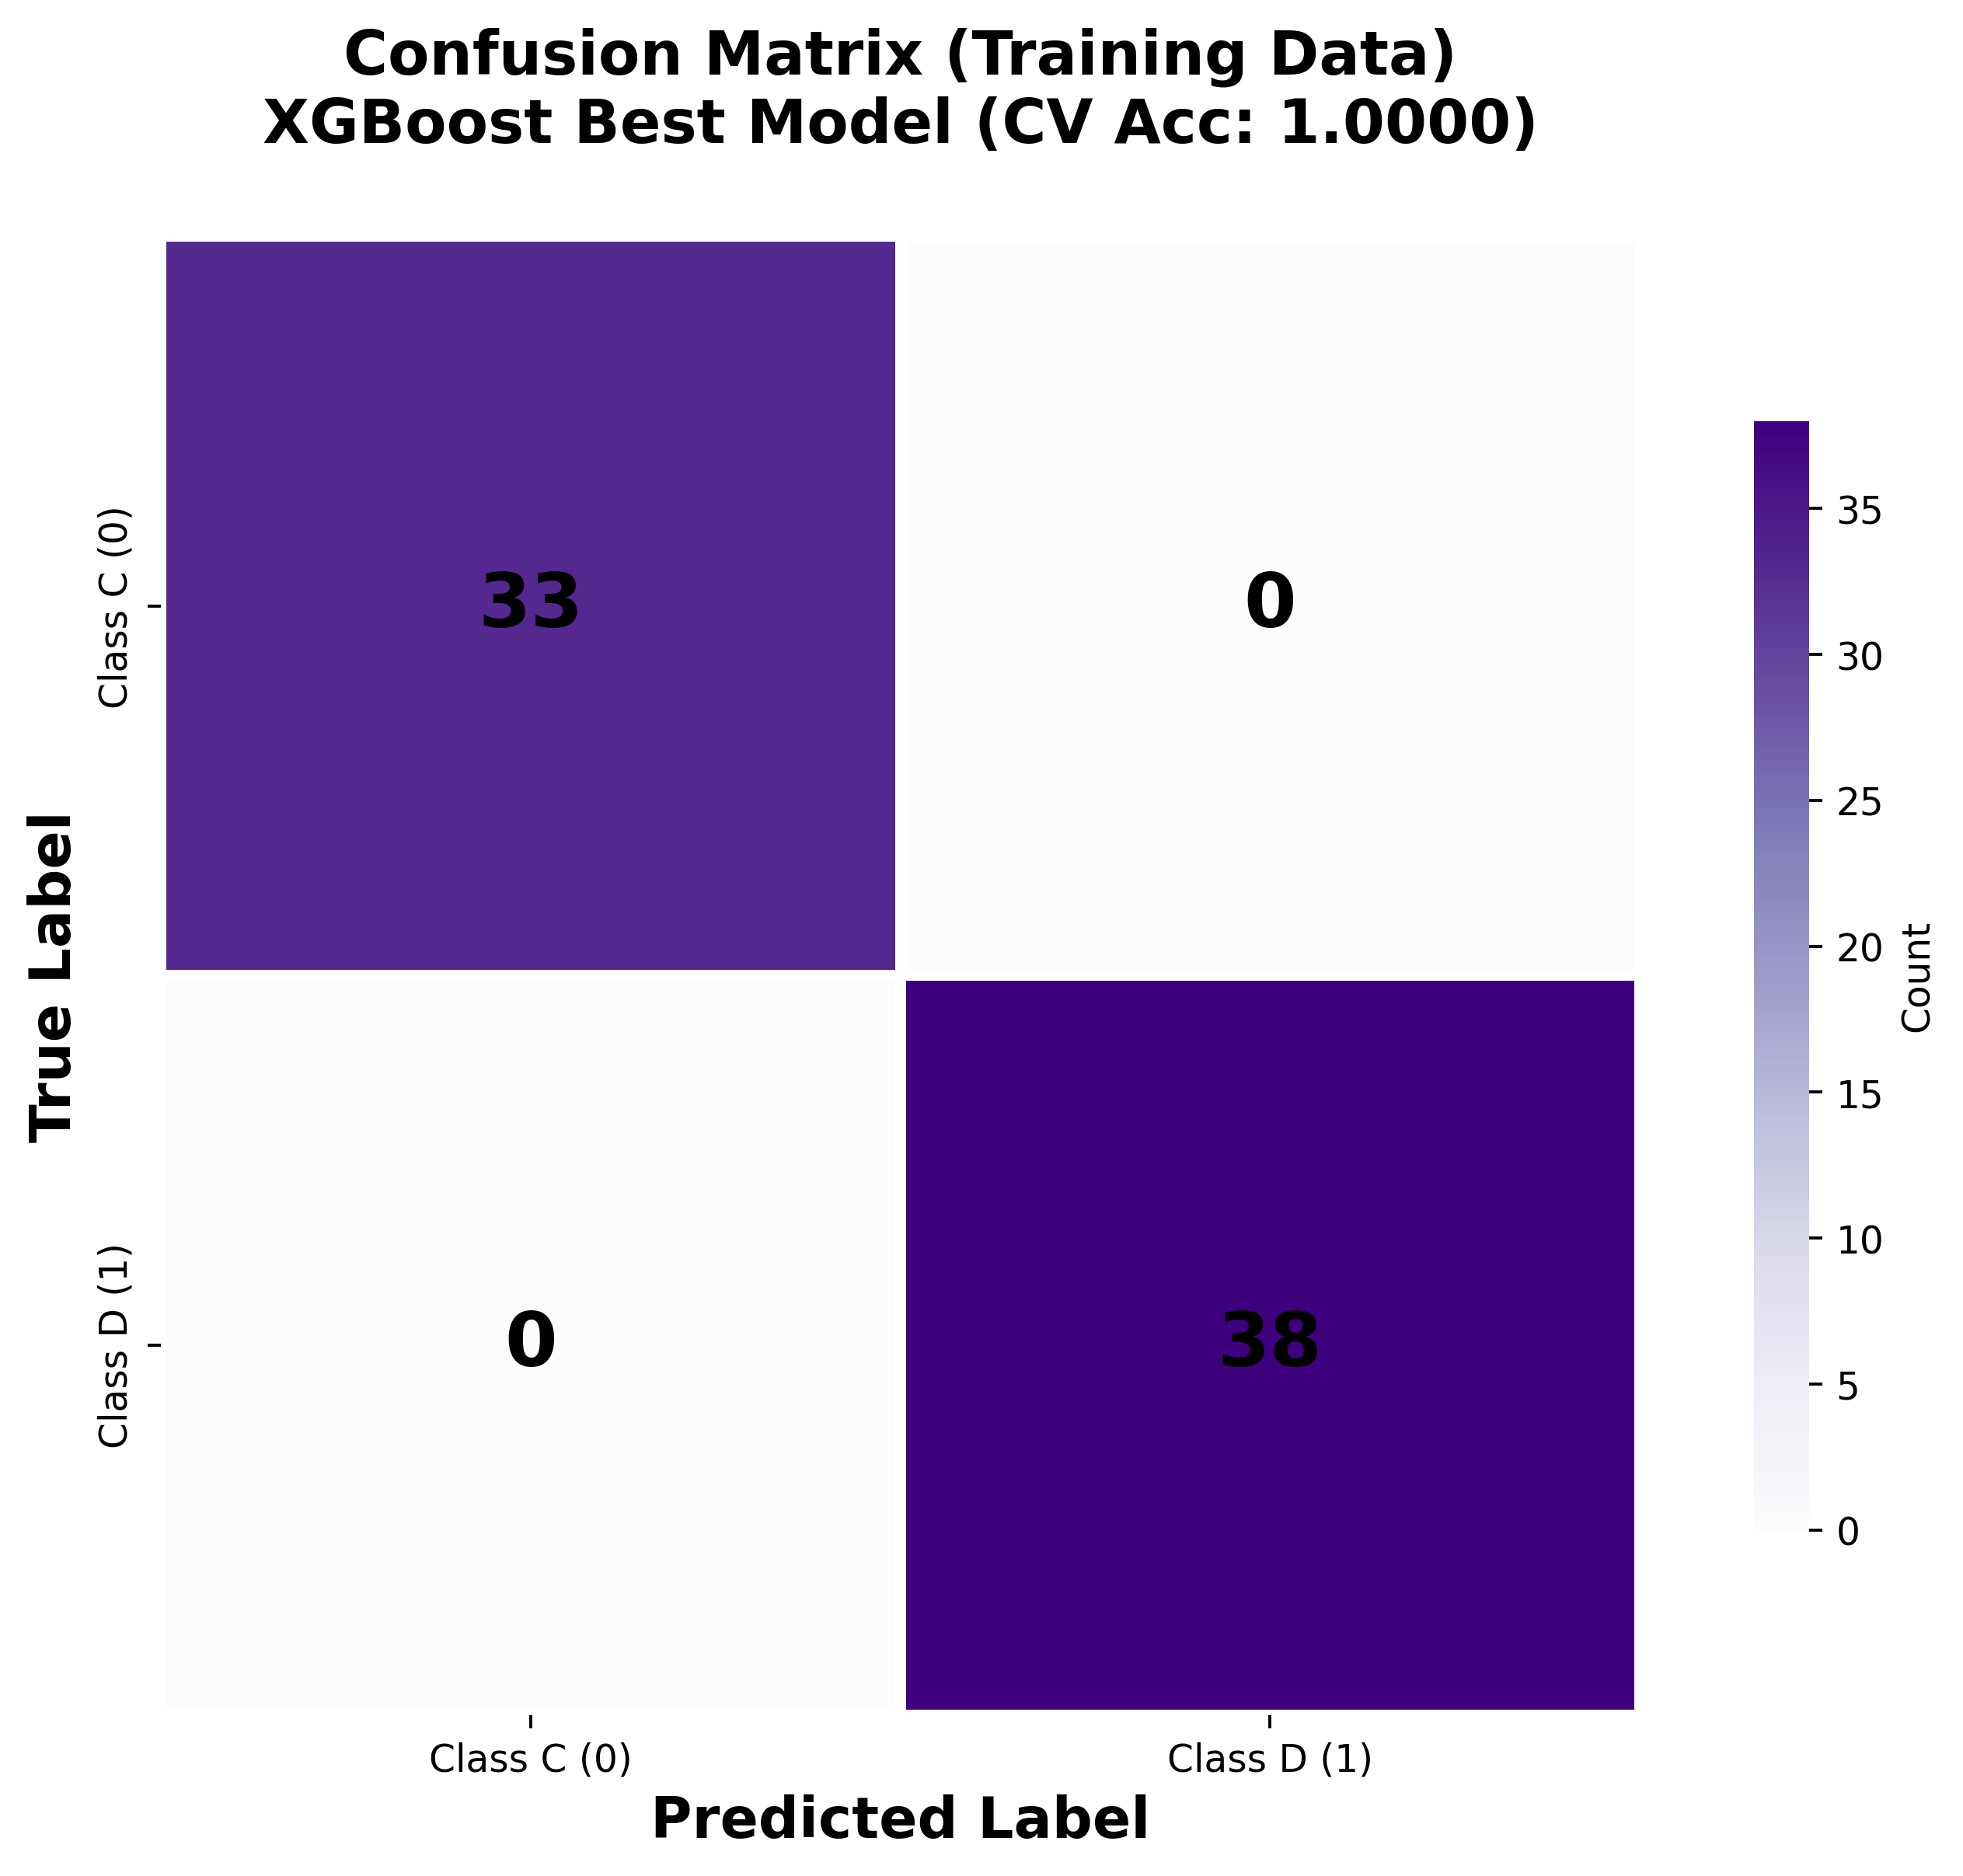

✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_20260606_083346.png'

FINAL MODEL PERFORMANCE ON TRAINING DATA
Best CV Accuracy : 1.0000
Training Accuracy: 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1-Score         : 1.0000
MCC              : 1.0000

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                33             0
True Class D                 0            38


In [ ]:



# ======================================================================
#  PINK CONFUSION MATRIX - BEST CV MODEL
# ======================================================================

y_pred = best_model.predict(X)
cm = confusion_matrix(y, y_pred)

plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nXGBoost Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.savefig(f'confusion_matrix_best_xgboost_{plot_timestamp}.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_{plot_timestamp}.png'")

# Metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE ON TRAINING DATA")
print("="*70)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\n" + "="*70)
print("CONFUSION MATRIX (Raw Counts)")
print("="*70)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [ ]:
print(type(best_model))
print(best_model)

print("Has estimators_:", hasattr(model, "estimators_"))

from sklearn.utils.validation import check_is_fitted

try:
    check_is_fitted(model)
    print("Model is fitted")
except Exception as e:
    print("Model NOT fitted")
    print(e)

<class 'sklearn.ensemble._weight_boosting.AdaBoostClassifier'>
AdaBoostClassifier(algorithm='SAMME',
                   estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=200, random_state=42)
Has estimators_: False
Model NOT fitted
This AdaBoostClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.



Calculating SHAP values...
Model fitted: True


  0%|          | 0/71 [00:00<?, ?it/s]

SHAP shape: (71, 49)
X shape   : (71, 49)


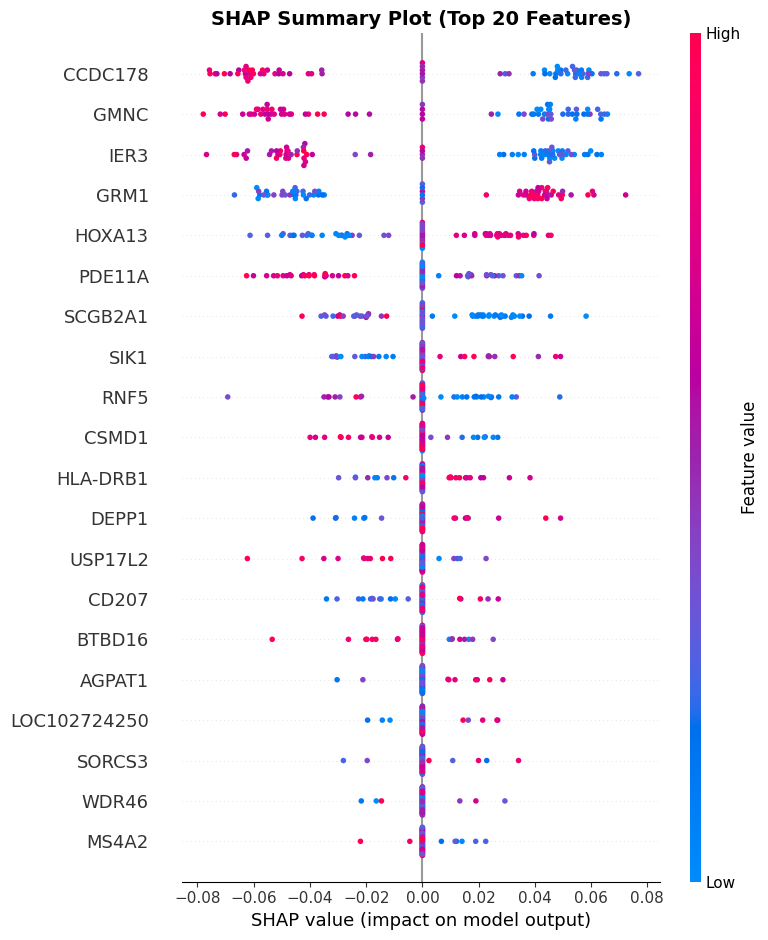

✅ Beeswarm saved


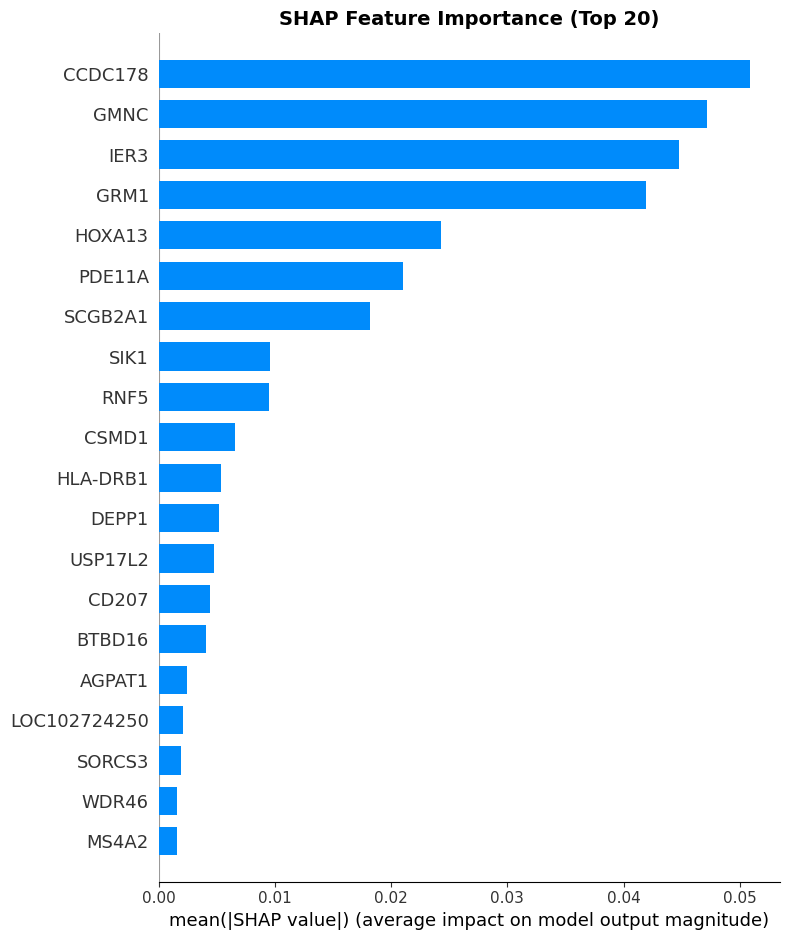

✅ Bar plot saved


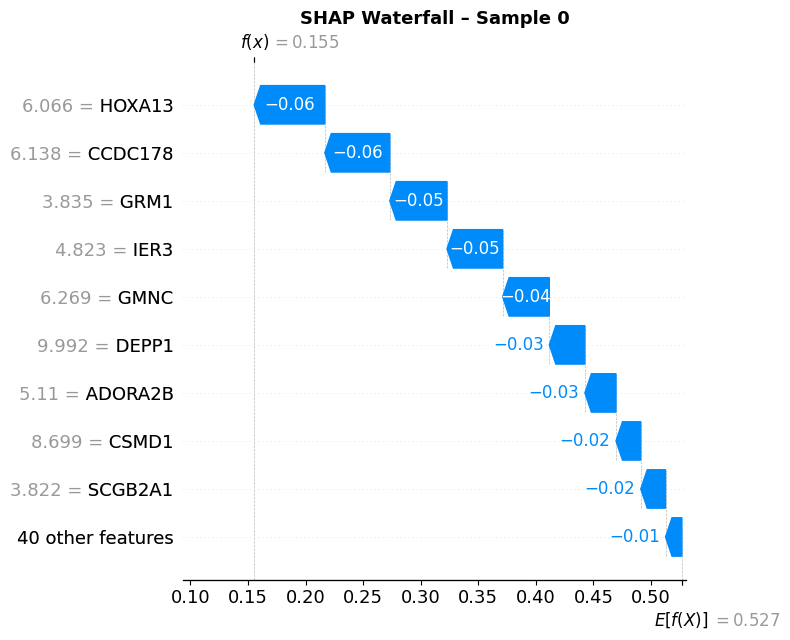

✅ Waterfall saved
✅ Importance CSV saved

Top 10 SHAP Features:
Feature  Mean_Abs_SHAP
CCDC178       0.050913
   GMNC       0.047155
   IER3       0.044774
   GRM1       0.041927
 HOXA13       0.024312
 PDE11A       0.020985
SCGB2A1       0.018213
   SIK1       0.009619
   RNF5       0.009522
  CSMD1       0.006537


In [ ]:
# ==========================
# SHAP ANALYSIS - ADABOOST
# ==========================
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

print("\nCalculating SHAP values...")

# Use fitted model from GridSearchCV
print("Model fitted:", hasattr(best_model, "estimators_"))

X_array = X.values.astype(np.float32)
feature_names = list(X.columns)

# Background dataset for KernelExplainer
background = shap.sample(X, 50, random_state=42)

# Create explainer
explainer = shap.KernelExplainer(
    best_model.predict_proba,
    background
)

# Calculate SHAP values
shap_values_raw = explainer.shap_values(
    X,
    nsamples=100
)

# ====================================================
# Handle SHAP output format
# ====================================================
if isinstance(shap_values_raw, list):

    shap_values = np.array(shap_values_raw[1])

    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = float(explainer.expected_value[1])
    else:
        base_val = float(explainer.expected_value)

else:

    arr = np.array(shap_values_raw)

    if arr.ndim == 3:
        # (samples, features, classes)
        shap_values = arr[:, :, 1]
    else:
        shap_values = arr

    ev = np.array(explainer.expected_value)

    if ev.ndim > 0:
        base_val = float(ev[1])
    else:
        base_val = float(ev)

print("SHAP shape:", shap_values.shape)
print("X shape   :", X_array.shape)
# ── 9a. Beeswarm Summary ────────────────────────────────────────────────────
plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    show=False, max_display=20
)
plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Beeswarm saved")

# ── 9b. Bar Plot ─────────────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    plot_type='bar',
    show=False, max_display=20
)
plt.title('SHAP Feature Importance (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_bar_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Bar plot saved")

# ── 9c. Waterfall (sample 0) — guaranteed 1D inputs ─────────────────────────
shap_exp = shap.Explanation(
    values        = shap_values[0],       # 1D (n_features,)
    base_values   = base_val,             # scalar float
    data          = X_array[0],           # 1D (n_features,)
    feature_names = feature_names
)

plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall – Sample 0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_{plot_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Waterfall saved")

# ── 9d. Importance CSV ───────────────────────────────────────────────────────
mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

mean_shap_df.to_csv(f'shap_importance_{plot_timestamp}.csv', index=False)
print(f"✅ Importance CSV saved")
print("\nTop 10 SHAP Features:")
print(mean_shap_df.head(10).to_string(index=False))

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [3]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [4]:
data = merged.T

In [ ]:
import pandas as pd

In [5]:

# Labels from row index
y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.values.astype(int)

# Feature matrix
data = data.reset_index(drop=True)
data.columns = data.iloc[0]
data = data.drop(data.index[0]).apply(pd.to_numeric)
X = data

In [6]:
import pickle
import joblib
best_model = joblib.load('/content/drive/MyDrive/ADA/10_2/adaboost_best_model.pkl')

# Open the file in read-binary mode



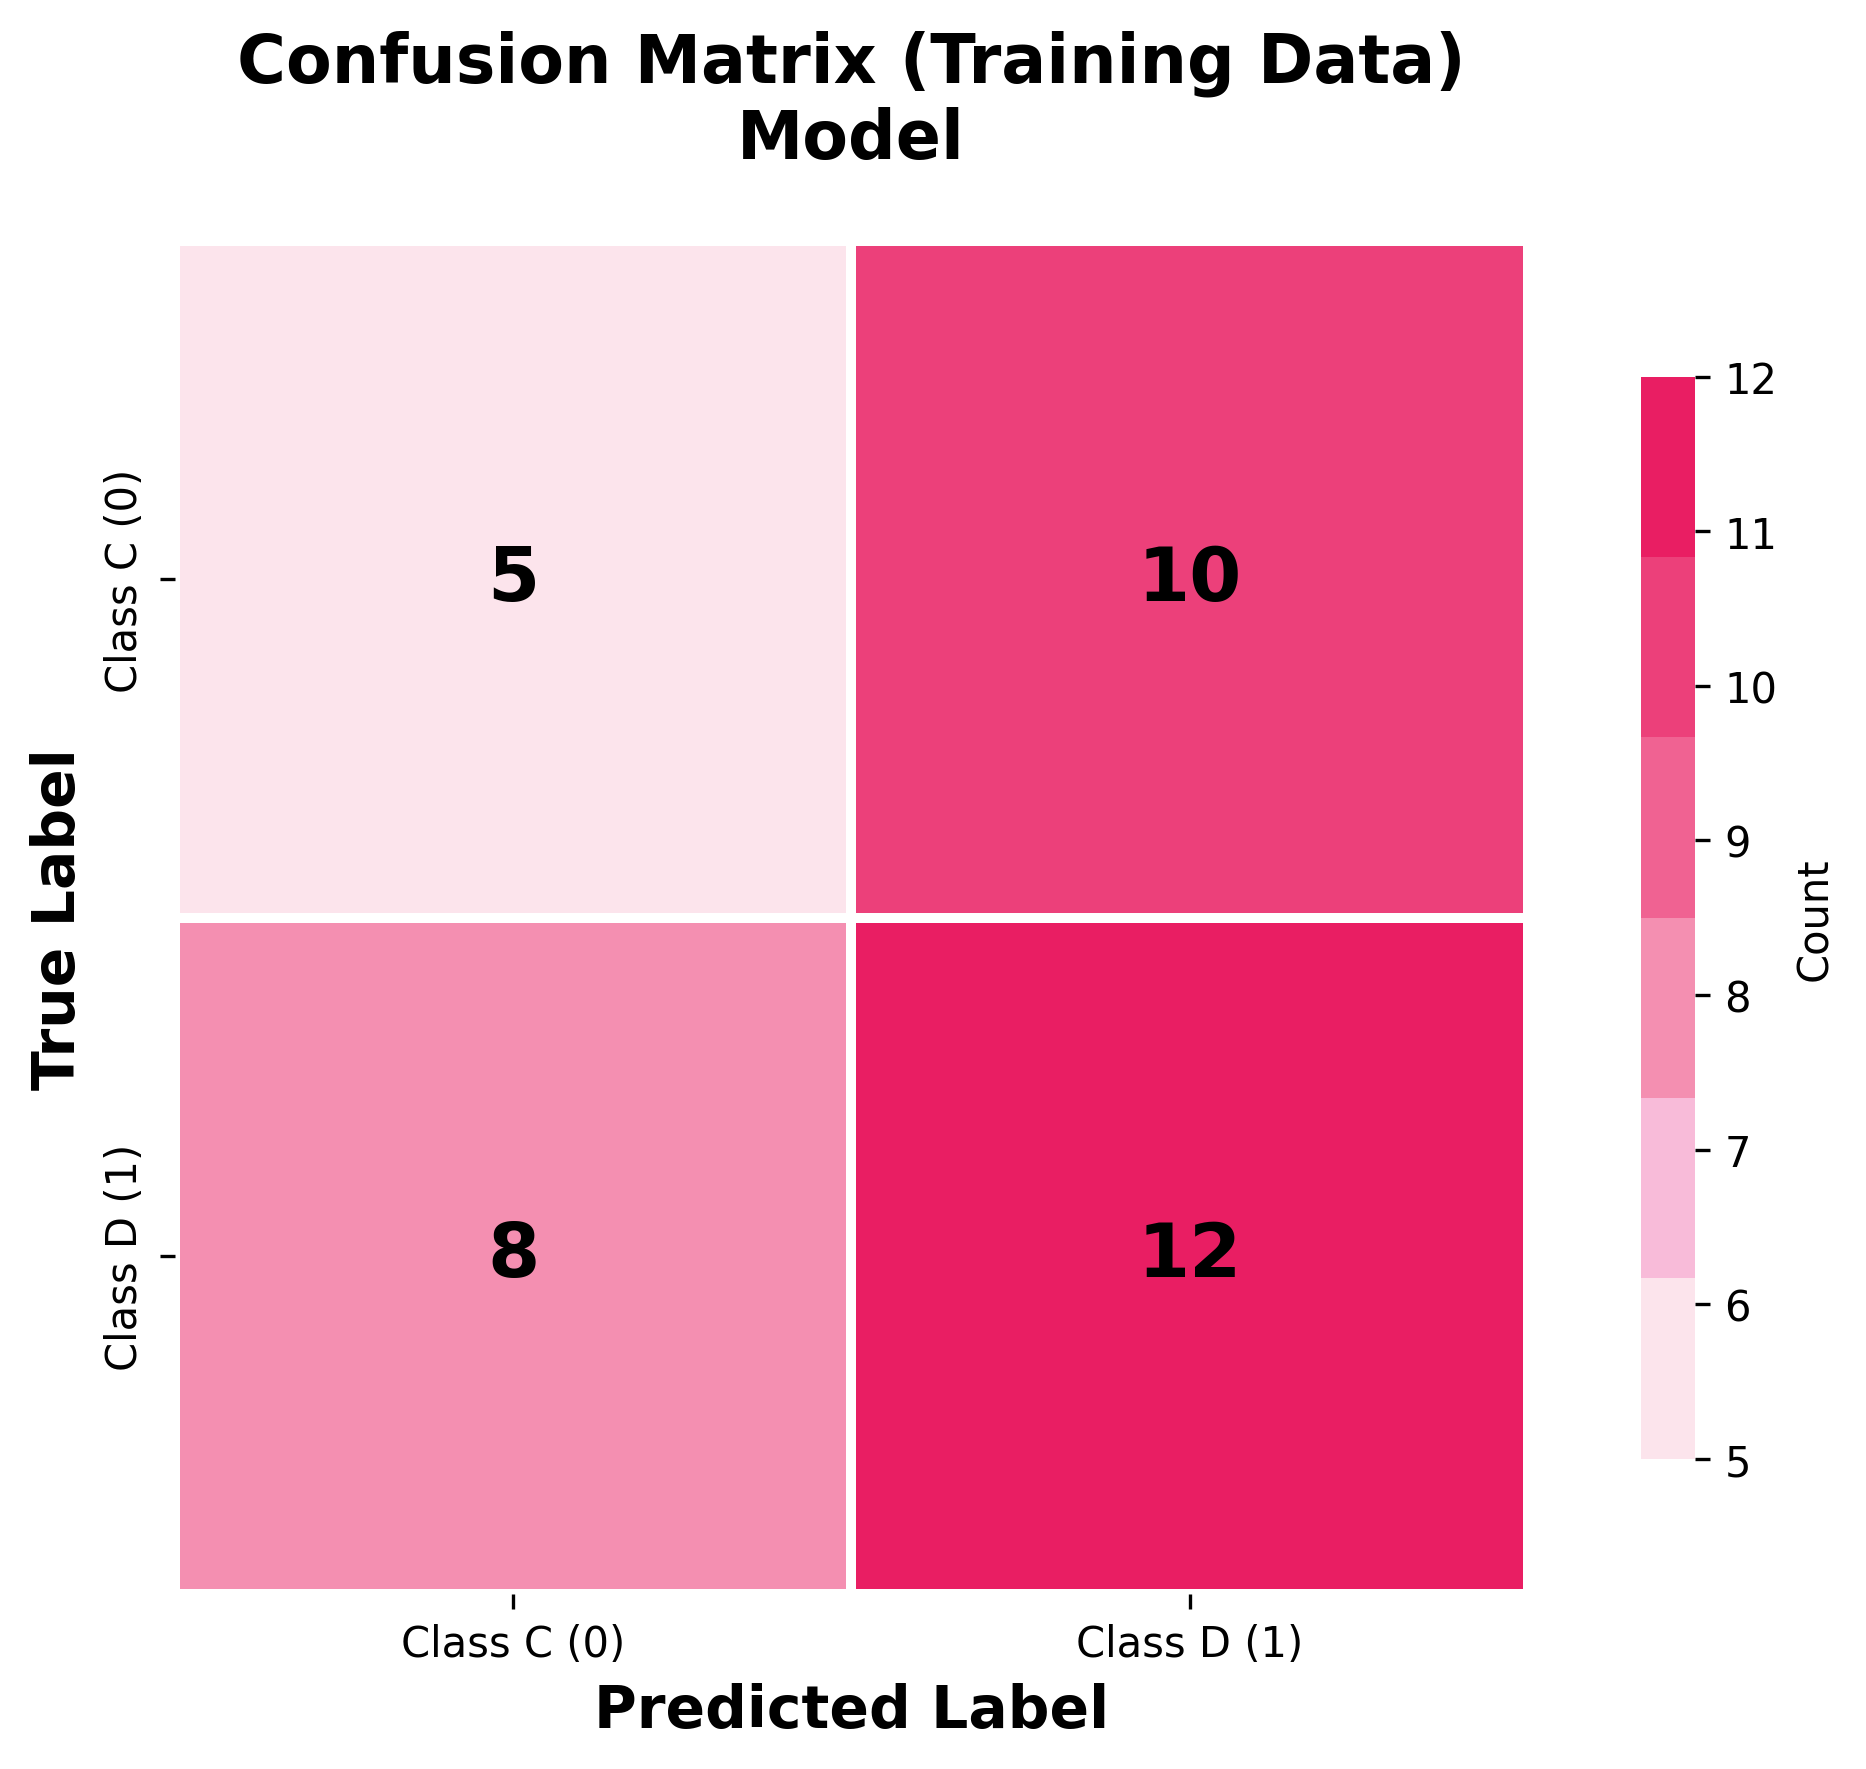


✅ Confusion matrix saved as 'confusion_matrix_20260624_052744.png'

MODEL PERFORMANCE METRICS
Accuracy:  0.4857
Precision: 0.5455
Recall:    0.6000
F1-Score:  0.5714
MCC:       -0.0683

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                 5            10
True Class D                 8            12


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap
X_val = X
y_val= y
# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = best_model.predict(X_val)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred)

# ============================================================
# PLOT PINK CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pink colormap
pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

# Title with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nModel',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    f'confusion_matrix.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print(f"\n✅ Confusion matrix saved as 'confusion_matrix_{timestamp}.png'")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [8]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime


# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(



📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.4857
ROC-AUC              : 0.4667
AUCPRC               : 0.5705
Avg Precision        : 0.5705
F1 Score             : 0.5714
F1 Macro             : 0.4643
F1 Weighted          : 0.4796
Precision            : 0.5455
Recall               : 0.6000
MCC                  : -0.0683

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.3846    0.3333    0.3571        15
           1     0.5455    0.6000    0.5714        20

    accuracy                         0.4857        35
   macro avg     0.4650    0.4667    0.4643        35
weighted avg     0.4765    0.4857    0.4796        35


✅ Metrics saved as 'validation_metrics_20260624_0527.csv'


In [9]:
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve


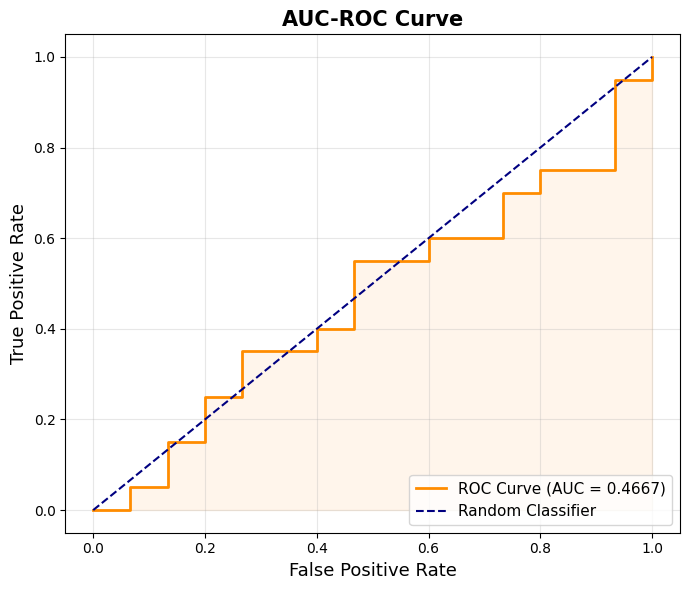

✅ AUC-ROC curve saved as 'aucroc_curve.png'


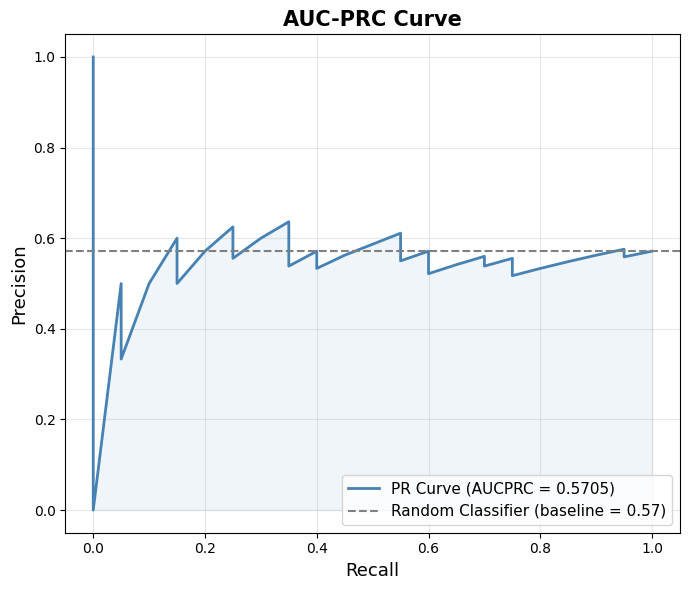

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [10]:

# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")

